In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_csv("datos_sesion1.csv")                 # Cargar dataset
df['tag'] = np.where(df['in_sf'] == 0, 'NY', 'SF')    # Agregar columna que identifique si es NY o SF
df.head()

,in_sf,beds,bath,price,year_built,sqft,price_per_sqft,elevation,tag
0,0,2.0,1.0,999000,1960,1000,999,10,NY
1,0,2.0,2.0,2750000,2006,1418,1939,0,NY
2,0,2.0,2.0,1350000,1900,2150,628,9,NY
3,0,1.0,1.0,629000,1903,500,1258,9,NY
4,0,0.0,1.0,439000,1930,500,878,10,NY


In [3]:
df_original = pd.read_csv("datos_sesion1.csv")

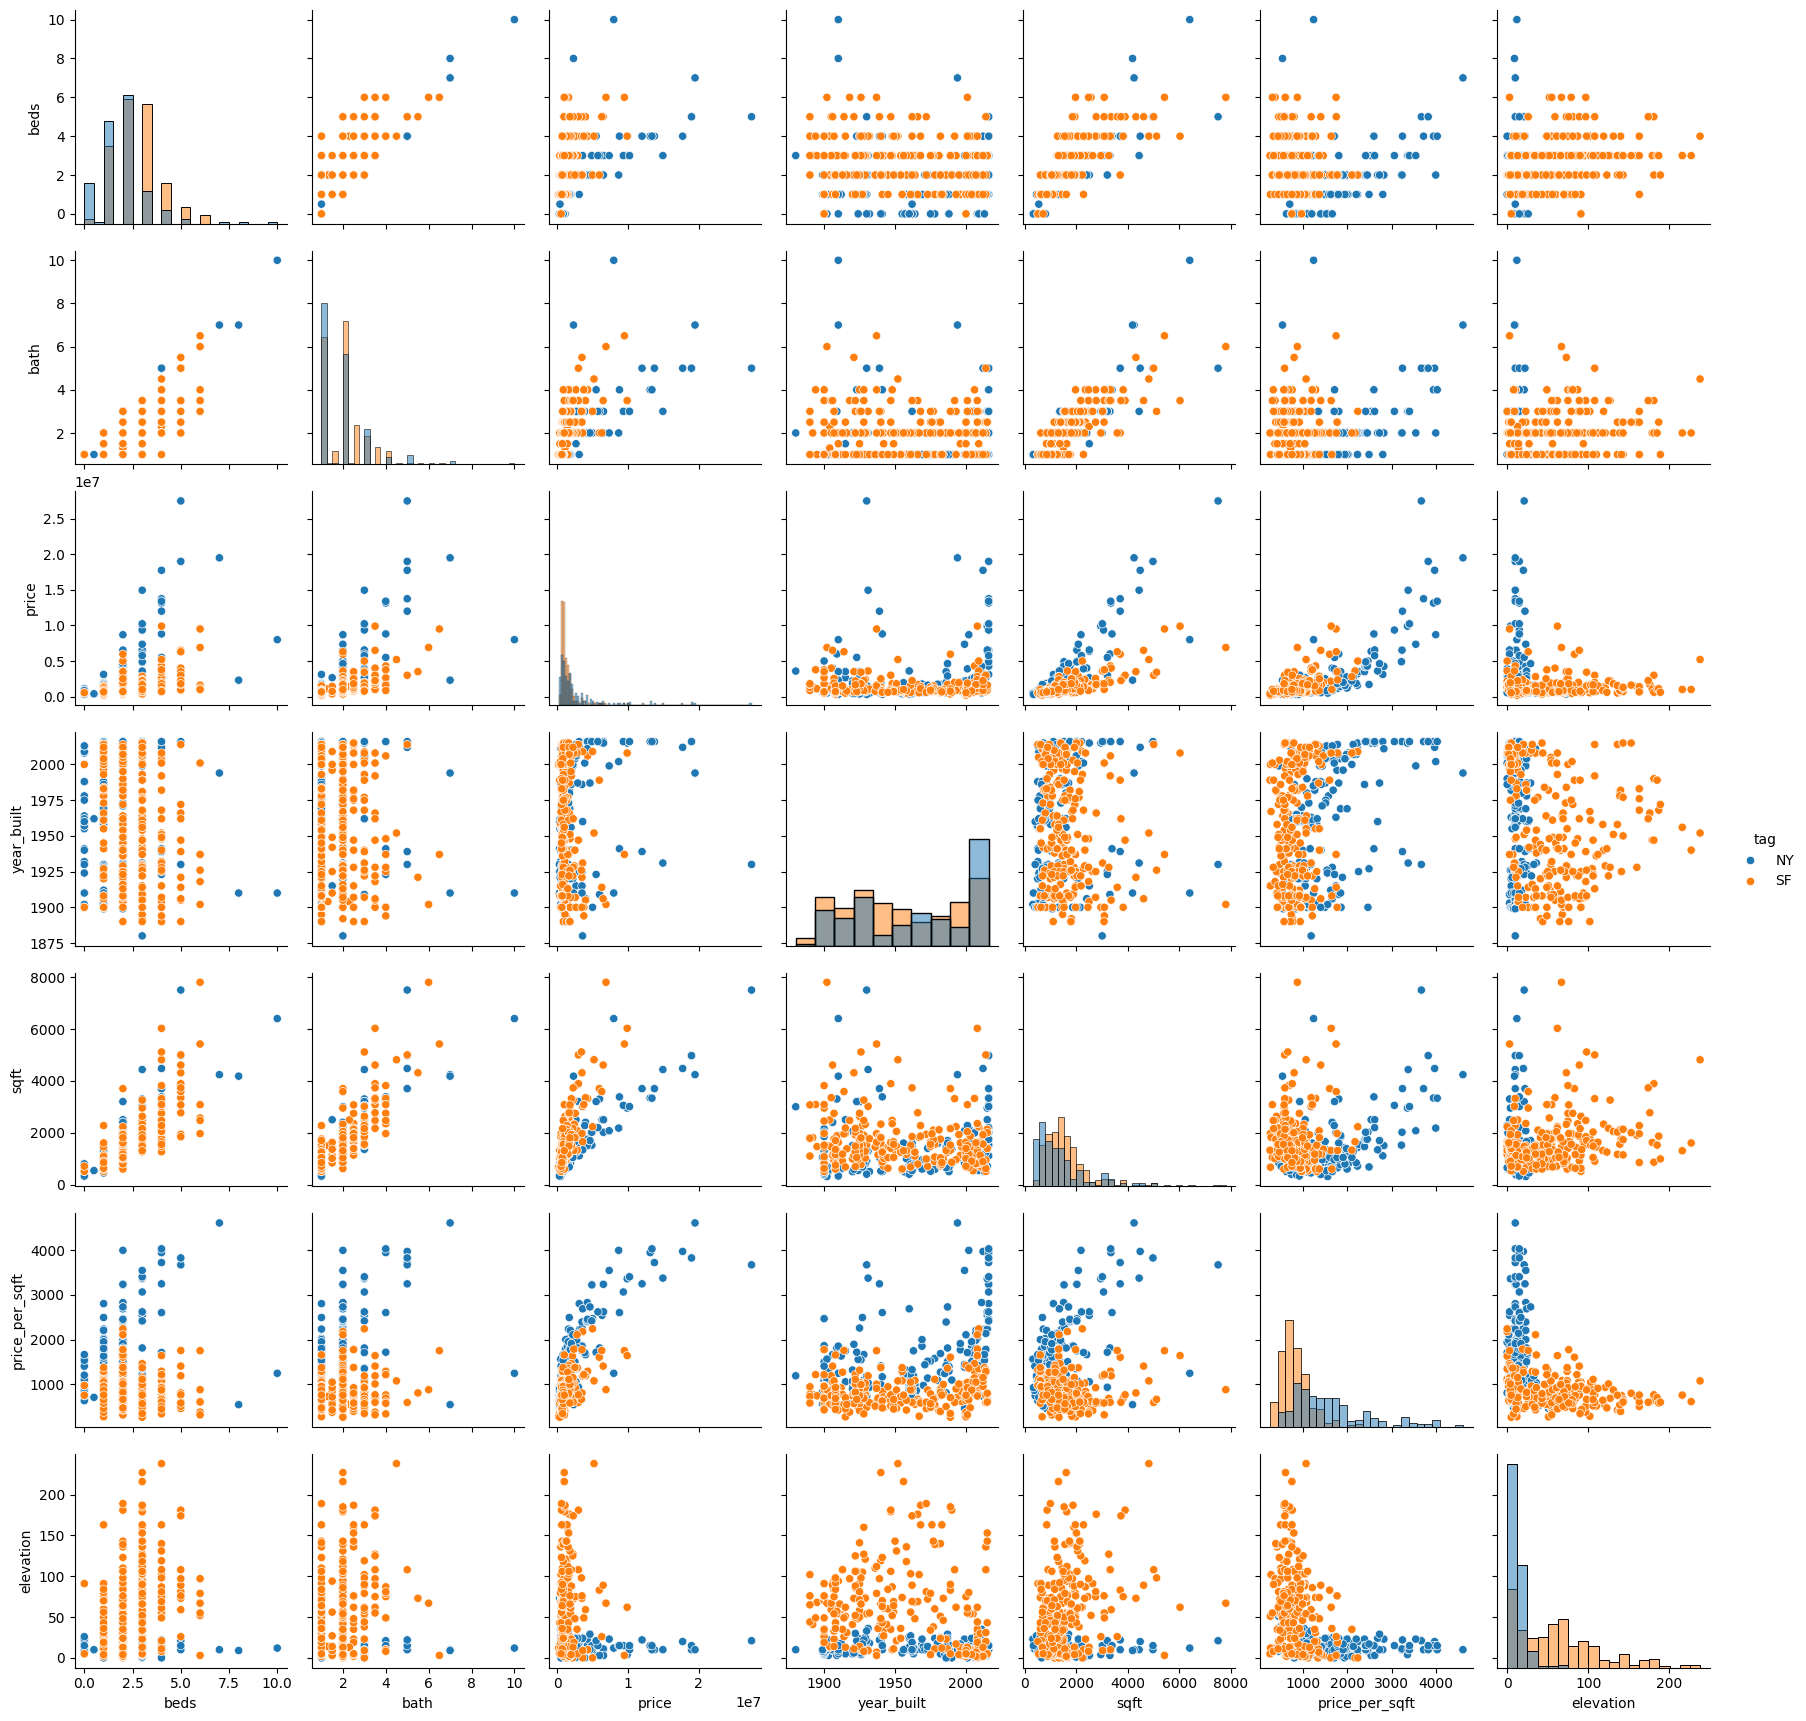

In [4]:
vars = [
    "beds", "bath", "price", "year_built",
    "sqft", "price_per_sqft", "elevation"
]

sns.pairplot(
    df,
    vars=vars,
    hue="tag",
    diag_kind="hist"   # o "kde"
)

plt.show()

### Scatter real
Relación entre elevación y precio por pie cuadrado

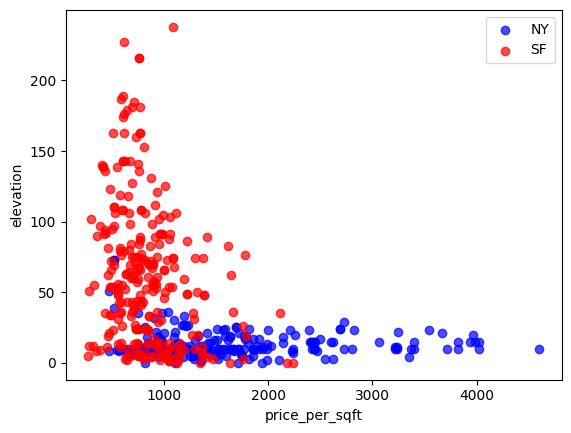

In [5]:
for val, color, label in [(0, 'blue', 'NY'), (1, 'red', 'SF')]:
    subset = df[df['in_sf'] == val]
    plt.scatter(subset['price_per_sqft'],subset['elevation'], c=color, label=label, alpha=0.7)

plt.xlabel('price_per_sqft')
plt.ylabel('elevation')
plt.legend()
plt.show()

### Reglas a usar

Tras explorar visualmente el dataset se determinan las siguientes reglas:

Elevation < 40 = NY

Price per sqft > 1000 = NY

Con estas reglas se podrá jugar editando las variables de la siguiente línea

In [7]:
# Variables para editar reglas
x_ele = 40
y_pps = 1000

In [8]:
# Genera columna de clasificación en base a los valores de la línea anterior
df['clasificacion'] = np.where((df['elevation'] < x_ele) & (df['price_per_sqft'] > y_pps), 'NY', 'SF')

# Compara nuestra columna creada (clasificacion) con el valor verdadero
acc1 = (df['clasificacion']==df['tag']).mean() 

In [9]:
df["correct1"] = df["tag"] == df["clasificacion"]

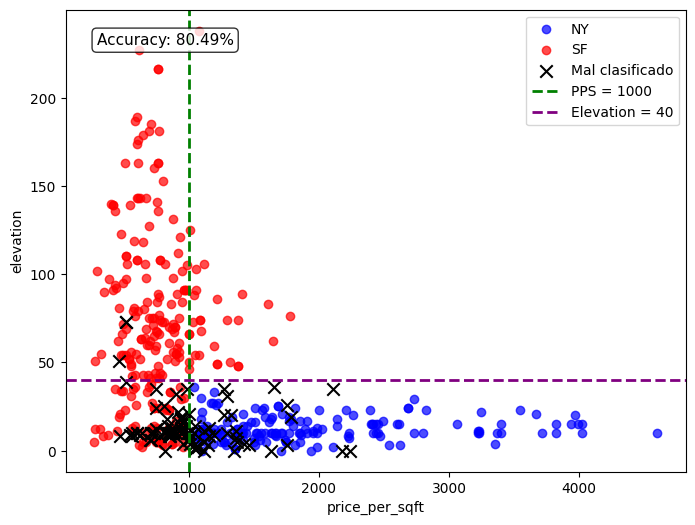

In [10]:
plt.figure(figsize=(8,6))

# NY correctamente clasificados
ny = df[(df["clasificacion"] == "NY") & (df["correct1"])]
plt.scatter(ny["price_per_sqft"], ny["elevation"],
            color="blue", label="NY", alpha=0.7)

# SF correctamente clasificados
sf = df[(df["clasificacion"] == "SF") & (df["correct1"])]
plt.scatter(sf["price_per_sqft"], sf["elevation"],
            color="red", label="SF", alpha=0.7)

# Mal clasificados
wrong = df[~df["correct1"]]
plt.scatter(wrong["price_per_sqft"], wrong["elevation"],
            color="black", marker="x", s=80,
            label="Mal clasificado")

plt.xlabel("price_per_sqft")
plt.ylabel("elevation")

plt.axvline(x=y_pps, color='green', linestyle='--', linewidth=2,
            label=f'PPS = {y_pps:.0f}')

plt.axhline(y=x_ele, color='purple', linestyle='--', linewidth=2,
            label=f'Elevation = {x_ele:.0f}')


plt.text(
    0.05, 0.95,
    f"Accuracy: {acc1:.2%}",
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.legend()
plt.show()

A prueba y error se vuelve una tarea extensa para buscar el mayor accuracy, por lo que se realizará el siguiente método

### Tendencia observada 1

A menor elevación y mayor ppsqft debe ser NY, caso contrario será SF

In [11]:
best_acc = 0     # Mejor accuracy, iniciado en 0
best_pps = None  # El pps que produjo dicha accuracy
best_ele = None  # La elevación que produjo dicha accuracy

for pps in sorted(df["price_per_sqft"].unique()):
    for ele in sorted(df["elevation"].unique()):

        pred = ((df["price_per_sqft"] > pps) & (df["elevation"] < ele)).map({True: "NY", False: "SF"})
        acc = (pred == df["tag"]).mean()

        if acc > best_acc:
            best_acc = acc
            best_pps = pps
            best_ele = ele

print(best_pps, best_ele, best_acc)

804 29 0.8434959349593496


- El doble ciclo anidado prueba cada combinación de (pps, ele) en el dataset.
- Según los parámetros de cada renglón del dataset se compara con la combinación actual y se asigna NY o SF.
- Ese valor asignado se compara con el valor real, obteniendo así el accuracy.

Llegando a los siguientes valores con un accuracy de 84.34%:

pps = 804

ele = 29

Poniendo esos valores en el primer código comprobamos el accuracy

### EDA
Se obtienen medidas de tendecia central para identificar que otra variable podría ser valiosa para la clasificación

In [12]:
df_original.groupby(df['in_sf']).mean()

,in_sf,beds,bath,price,year_built,sqft,price_per_sqft,elevation
in_sf,,,,,,,,
0,0.0,1.734375,1.819196,2.787579e+06,1965.142857,1398.044643,1626.522321,13.504464
1,1.0,2.507463,1.977985,1.379719e+06,1954.055970,1627.421642,835.485075,61.861940


In [13]:
df_original.groupby(df['in_sf']).median()

,in_sf,beds,bath,price,year_built,sqft,price_per_sqft,elevation
in_sf,,,,,,,,
0,0.0,2.0,2.0,1562500.0,1969.0,1050.0,1416.0,10.0
1,1.0,2.0,2.0,989000.0,1948.0,1450.0,768.5,55.0


Las variables utilizadas anteriormente (price_per_sqft, elevation) mustran la mayor diferencia en medias y medianas.

Observando las demás variables, se determina que "sqft" y "price" podrían ser variables con gran impacto para la clasificación.

### Scatter real
Relación entre elevación y pies cuadrados

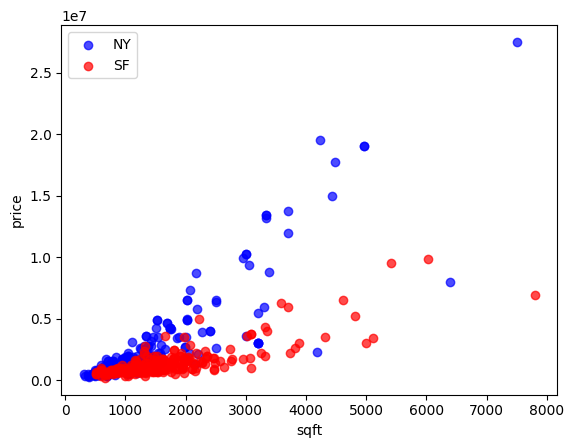

In [14]:
for val, color, label in [(0, 'blue', 'NY'), (1, 'red', 'SF')]:
    subset = df[df['in_sf'] == val]
    plt.scatter(subset['sqft'], subset['price'], c=color, label=label, alpha=0.7)

plt.xlabel('sqft')
plt.ylabel('price')
plt.legend()
plt.show()

### Tendencia observada 2

No es tan marcada la tendencia, sin embargo se puede deducir que en NY las viviendas tienden a ser mas caras

In [15]:
best_acc = 0     # Mejor accuracy, iniciado en 0
best_pri = None  # El precio que produjo dicha accuracy
best_sq  = None  # El área que produjo dicha accuracy

for pri in sorted(df["price"].unique()):
    for sq in sorted(df["sqft"].unique()):

        pred = ((df["price"] > pri) & (df["sqft"] < sq)).map({True: "NY", False: "SF"})
        acc = (pred == df["tag"]).mean()

        if acc > best_acc:
            best_acc = acc
            best_pri = pri
            best_sq  = sq

print(best_pri, best_sq, best_acc)

998000 1440 0.6544715447154471


Se busca el mejor valor de sqft y price en el mismo código que se encontró la elevación y el pps.

Llegando a los siguientes valores con un accuracy de 65.45%:

price = 998000

sqft = 1440

In [16]:
df['class_final'] = np.where(((df['elevation'] < 29) & (df['price_per_sqft'] > 804)) | ((df['price'] > 998000) & (df['sqft'] < 1440)), 'NY', 'SF')
acc2 = (df['class_final']==df['tag']).mean()
acc2

np.float64(0.8252032520325203)

In [17]:
df["correct2"] = df["tag"] == df["class_final"]

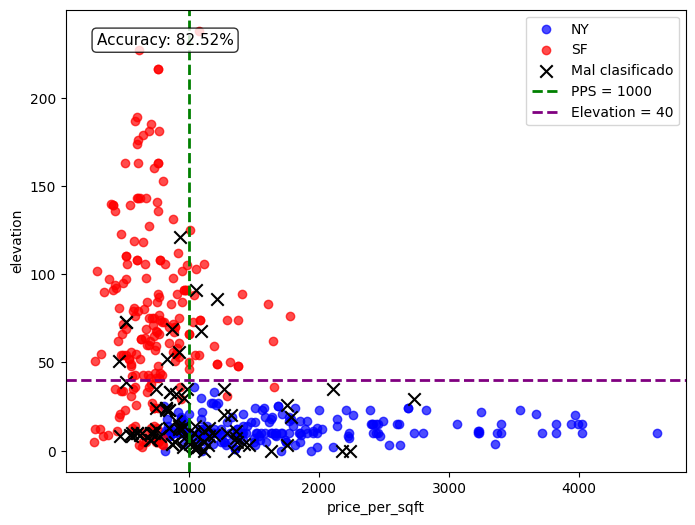

In [18]:
plt.figure(figsize=(8,6))

# NY correctamente clasificados
ny = df[(df["class_final"] == "NY") & (df["correct2"])]
plt.scatter(ny["price_per_sqft"], ny["elevation"],
            color="blue", label="NY", alpha=0.7)

# SF correctamente clasificados
sf = df[(df["class_final"] == "SF") & (df["correct2"])]
plt.scatter(sf["price_per_sqft"], sf["elevation"],
            color="red", label="SF", alpha=0.7)

# Mal clasificados
wrong = df[~df["correct2"]]
plt.scatter(wrong["price_per_sqft"], wrong["elevation"],
            color="black", marker="x", s=80,
            label="Mal clasificado")

plt.xlabel("price_per_sqft")
plt.ylabel("elevation")

plt.axvline(x=y_pps, color='green', linestyle='--', linewidth=2,
            label=f'PPS = {y_pps:.0f}')

plt.axhline(y=x_ele, color='purple', linestyle='--', linewidth=2,
            label=f'Elevation = {x_ele:.0f}')


plt.text(
    0.05, 0.95,
    f"Accuracy: {acc2:.2%}",
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.legend()
plt.show()

Agregando las reglas de price y sqft obtenidos a los de elevation y pps, el accuracy disminuye 2%

Se intentará un triple ciclo anidado con las dos variables originales (ele, pps) y la tercera siendo una de las nuevas observadas (price, sqft).

Se sabe que elevation es la variable con mayor impacto en la clasificación, por lo que se ajustarán las reglas

In [19]:
ele = df["elevation"].to_numpy()
pps = df["price_per_sqft"].to_numpy()
price = df["price"].to_numpy()
sqft = df["sqft"].to_numpy()
yr = df["year_built"].to_numpy()
beds = df["beds"].to_numpy()
baths = df["bath"].to_numpy()
tag = (df["tag"] == "NY").to_numpy()   # True si es NY

In [214]:
'''
best_acc = 0
best_ele = None
best_pps = None
best_price = None

for e in sorted(df["elevation"].unique()):
    for p in sorted(df["price_per_sqft"].unique()):
        for pr in sorted(df["price"].unique()):

            pred = (ele < e) & ((pps > p) | (price > pr)) # Ajuste de reglas
            acc = np.mean(pred == tag)

            if acc > best_acc:
                best_acc = acc
                best_ele, best_pps, best_price = e, p, pr

print(best_ele, best_pps, best_price, best_acc)

RESULTADO:
29 804 1800000 0.8455284552845529
'''

'\nbest_acc = 0\nbest_ele = None\nbest_pps = None\nbest_price = None\n\nfor e in sorted(df["elevation"].unique()):\n    for p in sorted(df["price_per_sqft"].unique()):\n        for pr in sorted(df["price"].unique()):\n\n            pred = (ele < e) & ((pps > p) | (price > pr)) # Ajuste de reglas\n            acc = np.mean(pred == tag)\n\n            if acc > best_acc:\n                best_acc = acc\n                best_ele, best_pps, best_price = e, p, pr\n\nprint(best_ele, best_pps, best_price, best_acc)\n\nRESULTADO:\n29 804 1800000 0.8455284552845529\n'

In [20]:
best_acc = 0
best_ele = None
best_pps = None
best_sqft = None

for e in sorted(df["elevation"].unique()):
    for p in sorted(df["price_per_sqft"].unique()):
        for sq in sorted(df["sqft"].unique()):

            pred = (ele < e) & ((pps > p) | (sqft < sq)) # Ajuste de reglas
            acc = np.mean(pred == tag)

            if acc > best_acc:
                best_acc = acc
                best_ele, best_pps, best_sqft = e, p, sq

print(best_ele, best_pps, best_sqft, best_acc)

34 1053 756 0.8739837398373984


In [21]:
df['class_final'] = np.where((df['elevation'] < 34) & ((df['price_per_sqft'] > 1053) | (df['sqft'] < 756)), 'NY', 'SF')
acc2 = (df['class_final']==df['tag']).mean()
acc2

np.float64(0.8739837398373984)

In [22]:
df["correct"] = df["tag"] == df["class_final"]

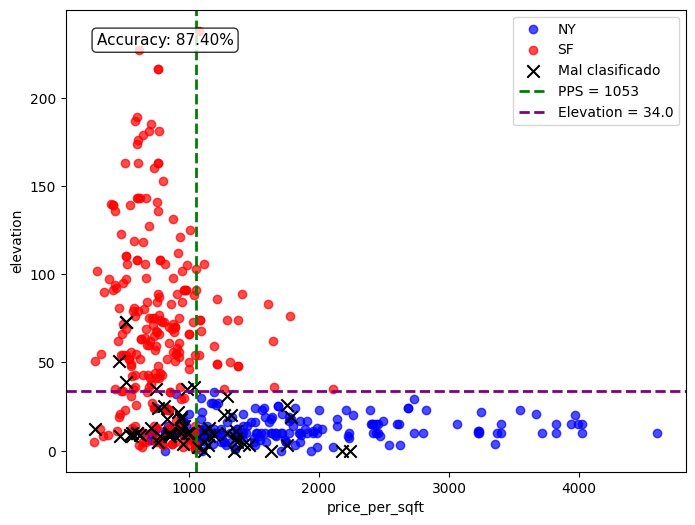

In [23]:
plt.figure(figsize=(8,6))

# NY correctamente clasificados
ny = df[(df["class_final"] == "NY") & (df["correct"])]
plt.scatter(ny["price_per_sqft"], ny["elevation"],
            color="blue", label="NY", alpha=0.7)

# SF correctamente clasificados
sf = df[(df["class_final"] == "SF") & (df["correct"])]
plt.scatter(sf["price_per_sqft"], sf["elevation"],
            color="red", label="SF", alpha=0.7)

# Mal clasificados
wrong = df[~df["correct"]]
plt.scatter(wrong["price_per_sqft"], wrong["elevation"],
            color="black", marker="x", s=80,
            label="Mal clasificado")

plt.xlabel("price_per_sqft")
plt.ylabel("elevation")

plt.axvline(x=best_pps, color='green', linestyle='--', linewidth=2,
            label=f'PPS = {best_pps:.0f}')

plt.axhline(y=best_ele, color='purple', linestyle='--', linewidth=2,
            label=f'Elevation = {best_ele:.1f}')


plt.text(
    0.05, 0.95,
    f"Accuracy: {acc2:.2%}",
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.legend()
plt.show()

In [213]:
'''
best_acc = 0
best_ele = None
best_price = None
best_sqft = None

for e in sorted(df["elevation"].unique()):
    for p in sorted(df["price"].unique()):
        for sq in sorted(df["sqft"].unique()):

            pred = (ele < e) & ((price > p) | (sqft < sq)) # Ajuste de reglas
            acc = np.mean(pred == tag)

            if acc > best_acc:
                best_acc = acc
                best_ele, best_price, best_sqft = e, p, sq

print(best_ele, best_price, best_sqft, best_acc)

RESULTADO:
31 1097000 824 0.8577235772357723
'''

'\nbest_acc = 0\nbest_ele = None\nbest_price = None\nbest_sqft = None\n\nfor e in sorted(df["elevation"].unique()):\n    for p in sorted(df["price"].unique()):\n        for sq in sorted(df["sqft"].unique()):\n\n            pred = (ele < e) & ((price > p) | (sqft < sq)) # Ajuste de reglas\n            acc = np.mean(pred == tag)\n\n            if acc > best_acc:\n                best_acc = acc\n                best_ele, best_price, best_sqft = e, p, sq\n\nprint(best_ele, best_price, best_sqft, best_acc)\n\nRESULTADO:\n31 1097000 824 0.8577235772357723\n'

In [232]:
from sklearn.metrics import confusion_matrix

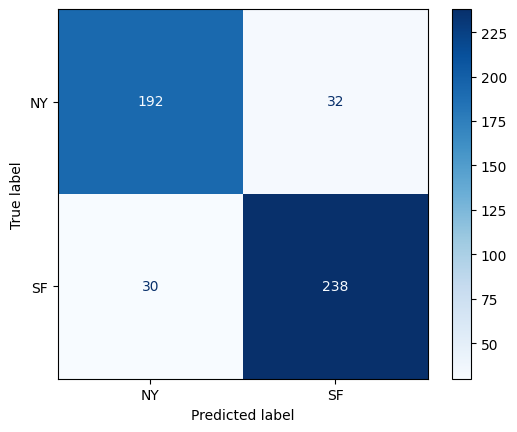

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    df["tag"],
    df["class_final"],
    labels=["NY", "SF"],
    cmap="Blues"
)

plt.show()